# Event Frequency Modelling using GLMs (Insurance Case Study)

This project develops an exposure-adjusted statistical model to predict event frequency using the freMTPL2 motor insurance dataset.

The objective is to model how often events (claims) occur, rather than whether they occur, using Generalized Linear Models (GLMs) suited for count data.

The analysis includes:
- Exploratory risk segmentation across key variables
- Exposure-adjusted Poisson regression as a baseline model
- Overdispersion testing to assess model assumptions
- Negative Binomial regression to address excess variability
- Model validation using calibration and out-of-sample evaluation

This framework is widely applicable across domains such as insurance (claims), banking (default frequency), and business analytics (customer event modelling).


## Project Overview

This project focuses on modelling event frequency using exposure-adjusted Generalized Linear Models (GLMs).

Unlike classification problems that predict whether an event occurs, this analysis models the number of events occurring over a given exposure period.

We use:
- Poisson regression as a baseline model for count data
- Overdispersion testing to validate model assumptions
- Negative Binomial regression to handle excess variability in claim counts

A log-exposure offset is incorporated to account for varying policy durations, ensuring fair comparison across observations.

The goal is to build a statistically robust and interpretable frequency model, evaluate its predictive performance, and derive insights relevant for risk assessment and decision-making.

## Dataset Overview

This project uses the freMTPL2 motor insurance dataset, which contains policy-level information for claim frequency analysis.

Key variables include:
- **ClaimNb**: Number of claims reported (target variable)
- **Exposure**: Duration for which the policy was active (used for exposure adjustment)
- **DriverAge**: Age of the driver (risk indicator)
- **VehAge**: Age of the vehicle (risk indicator)
- **BonusMalus**: Policyholder risk score based on claim history
- **VehPower**: Vehicle power category (proxy for driving behavior and risk)
- **Density**: Population density (proxy for traffic and environmental risk)

Since policies vary in exposure duration, modelling must account for exposure to ensure fair and unbiased comparison.

This dataset is well-suited for exposure-adjusted frequency modelling using GLMs.

## Data Loading

The dataset is loaded and basic structure is examined.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [56]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/freMTPL2.csv")

print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns")

Dataset contains 678013 rows and 12 columns


The dataset contains over 670,000 policy records with multiple risk-related features, providing a strong basis for frequency modelling.

## Data Quality Checks

The dataset is evaluated for missing values, duplicates, and invalid ranges to ensure reliability for modelling.

Since frequency modelling depends on both claim counts and exposure, data consistency is critical before fitting statistical models.

Checks performed include:
- Missing values across all variables
- Duplicate records
- Invalid values (e.g., negative claims, non-positive exposure)

In [57]:
df.isnull().sum()
df.duplicated().sum()

invalid_checks = {
    "Negative ClaimNb": (df['ClaimNb'] < 0).sum(),
    "Non-positive Exposure": (df['Exposure'] <= 0).sum(),
    "Negative BonusMalus": (df['BonusMalus'] < 0).sum(),
    "Negative VehAge": (df['VehAge'] < 0).sum(),
    "Negative DrivAge": (df['DrivAge'] < 0).sum(),
    "Negative Density": (df['Density'] < 0).sum()
}

invalid_checks

{'Negative ClaimNb': np.int64(0),
 'Non-positive Exposure': np.int64(0),
 'Negative BonusMalus': np.int64(0),
 'Negative VehAge': np.int64(0),
 'Negative DrivAge': np.int64(0),
 'Negative Density': np.int64(0)}

No missing values, duplicates, or invalid ranges were detected in key variables.

The dataset is suitable for exposure-adjusted frequency modelling, as it contains consistent claim counts and exposure information required for GLM-based approaches.

### Data Quality Summary

No missing values, duplicates, or invalid ranges were detected in key variables.

This confirms that the dataset is clean and suitable for exposure-adjusted GLM modelling, ensuring reliable downstream analysis.

## Claim Count Distribution

We begin by examining the distribution of claim counts to assess the suitability of count-based statistical models.

Understanding the distribution is critical, as it reveals key characteristics such as sparsity, skewness, and variability, which directly influence model selection.

In insurance portfolios, claim counts are typically sparse, with a large proportion of policies reporting zero claims. This characteristic must be accounted for when choosing an appropriate modelling approach.

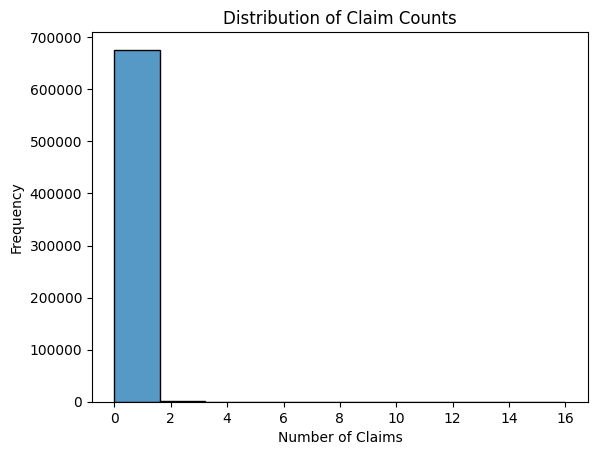

In [58]:
sns.histplot(df["ClaimNb"], bins=10)
plt.title("Distribution of Claim Counts")
plt.xlabel("Number of Claims")
plt.ylabel("Frequency")
plt.show()

In [59]:
zero_claims = (df['ClaimNb'] == 0).mean()
mean_claims = df['ClaimNb'].mean()
variance_claims = df['ClaimNb'].var()

print(f"Proportion of zero-claim policies: {round(zero_claims,4)}")
print(f"Mean of ClaimNb: {round(mean_claims,4)}")
print(f"Variance of ClaimNb: {round(variance_claims,4)}")

Proportion of zero-claim policies: 0.9498
Mean of ClaimNb: 0.0532
Variance of ClaimNb: 0.0577


### Key Observations

- Claim counts are highly skewed, with the majority of policies reporting zero claims
- Approximately 95% of policies have no claims, indicating strong sparsity in the data
- The variance exceeds the mean, suggesting the presence of overdispersion

This violates the equidispersion assumption of the Poisson model and indicates that a more flexible model, such as the Negative Binomial, may provide a better fit.

## Portfolio Claim Frequency

Claim frequency represents the expected number of claims per unit of exposure.

It provides a baseline measure of risk across the portfolio before applying predictive models.

Estimating the overall claim frequency helps contextualize how rare or frequent events are, which is essential for interpreting model outputs.

In [60]:
total_claims = df['ClaimNb'].sum()
total_exposure = df['Exposure'].sum()

claim_frequency = total_claims / total_exposure

print(f"Portfolio Claim Frequency: {round(claim_frequency,4)}")

Portfolio Claim Frequency: 0.1007


The portfolio claim frequency is approximately 0.10 claims per policy-year, indicating that claims are relatively rare events.

This further supports the use of count-based statistical models and highlights the importance of handling sparse data appropriately in the modelling process.

## Claim Frequency by Driver Age

Driver age is evaluated as a key risk segmentation variable.

We analyze exposure-adjusted claim frequency across driver age bands to assess whether risk varies systematically across different age groups.

This helps determine whether driver age should be included as a predictive feature in the frequency model.

In [61]:
df["driver_age_band"] = pd.cut(
    df["DrivAge"],
    bins=[18, 25, 35, 50, 70, np.inf],
    labels=["18-25", "26-35", "36-50", "51-70", "70+"],
    include_lowest=True
)

In [62]:
driver_age_summary = df.groupby("driver_age_band", observed=False).agg(
    total_claims=("ClaimNb", "sum"),
    total_exposure=("Exposure", "sum")
).reset_index()

driver_age_summary["claim_frequency"] = (
    driver_age_summary["total_claims"] / driver_age_summary["total_exposure"]
)

driver_age_summary

,driver_age_band,total_claims,total_exposure,claim_frequency
0,18-25,2841,16227.903263,0.175069
1,26-35,6662,69266.778075,0.096179
2,36-50,13118,131989.064957,0.099387
3,51-70,10858,114060.324541,0.095195
4,70+,2623,26955.374625,0.097309


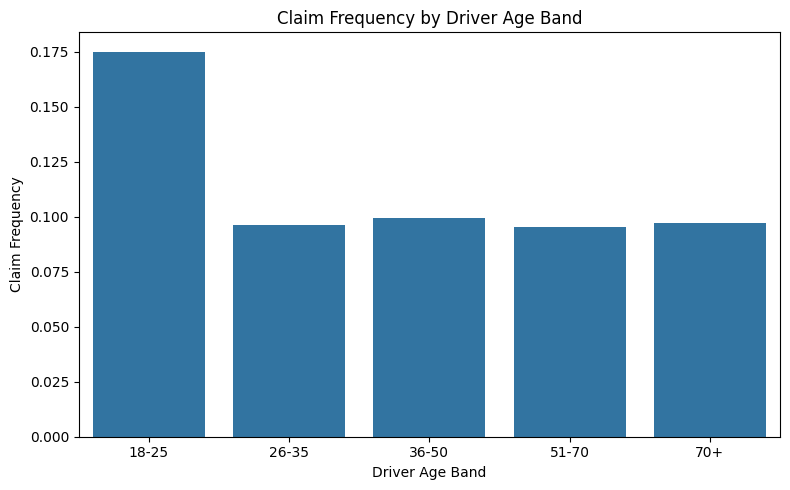

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=driver_age_summary["driver_age_band"],
    y=driver_age_summary["claim_frequency"]
)

plt.title("Claim Frequency by Driver Age Band")
plt.xlabel("Driver Age Band")
plt.ylabel("Claim Frequency")
plt.tight_layout()
plt.savefig("../visuals/driver_age_risk.png")
plt.show()

### Interpretation

Driver age shows a clear relationship with claim frequency.

The 18–25 segment exhibits the highest claim frequency, indicating elevated risk among younger drivers. Middle-aged and older groups show lower and relatively stable frequencies.

This suggests that driver age is a strong risk segmentation variable and is likely to be an important predictor in the frequency model.

From a modelling perspective, this variable is expected to contribute meaningfully to explaining variation in claim frequency.

This pattern will be further validated through the GLM framework to assess its statistical significance and impact on predicted claim frequency.

## Claim Frequency by Vehicle Age

Vehicle age is evaluated as a potential risk segmentation variable.

We compare exposure-adjusted claim frequency across vehicle age bands to assess whether claim frequency changes systematically with vehicle age.

This helps determine whether vehicle age should be retained as a meaningful predictor in the frequency model.

In [64]:
df["vehicle_age_band"] = pd.cut(
    df["VehAge"],
    bins=[0, 5, 10, 15, 20, np.inf],
    labels=["0-5", "6-10", "11-15", "16-20", "20+"],
    include_lowest=True
)

In [65]:
vehicle_age_summary = df.groupby("vehicle_age_band", observed=False).agg(
    total_claims=("ClaimNb", "sum"),
    total_exposure=("Exposure", "sum")
).reset_index()

vehicle_age_summary["claim_frequency"] = (
    vehicle_age_summary["total_claims"] / vehicle_age_summary["total_exposure"]
)

vehicle_age_summary

,vehicle_age_band,total_claims,total_exposure,claim_frequency
0,0-5,17647,151216.179124,0.116700
1,6-10,9846,99008.916360,0.099446
2,11-15,6648,77990.975407,0.085241
3,16-20,1685,25136.158607,0.067035
4,20+,276,5147.215965,0.053621


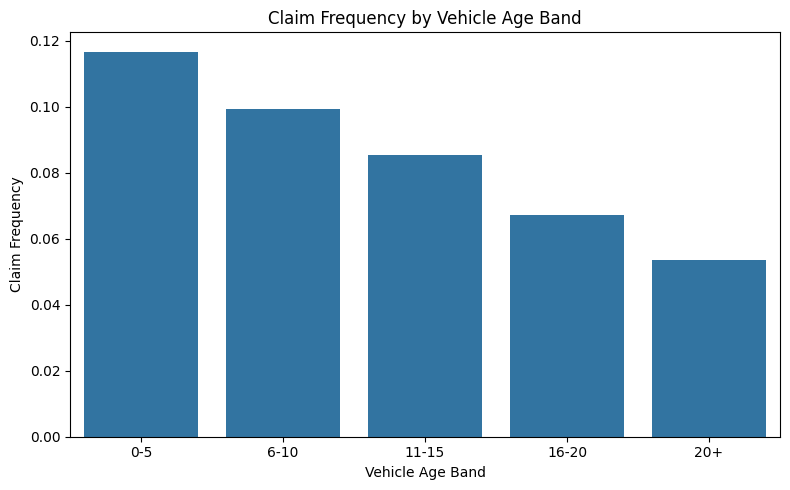

In [66]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=vehicle_age_summary["vehicle_age_band"],
    y=vehicle_age_summary["claim_frequency"]
)

plt.title("Claim Frequency by Vehicle Age Band")
plt.xlabel("Vehicle Age Band")
plt.ylabel("Claim Frequency")
plt.tight_layout()
plt.savefig("../visuals/vehicle_age_risk.png")
plt.show()

### Interpretation

Claim frequency declines steadily as vehicle age increases, with newer vehicles showing the highest observed frequency.

This indicates that vehicle age is associated with meaningful differences in observed risk, although the effect appears less pronounced than the Bonus-Malus pattern.

From a modelling perspective, vehicle age appears to be a useful explanatory variable and will be evaluated further within the GLM framework.

This relationship will be tested within the regression model to assess whether the observed pattern remains statistically significant after controlling for other variables.

## Claim Frequency by Bonus-Malus Band

Bonus-Malus is evaluated as a key behavioural and historical risk indicator linked to prior claims experience.

We compare exposure-adjusted claim frequency across Bonus-Malus bands to assess whether prior claims history is associated with current claim frequency.

This helps determine whether Bonus-Malus should play a central role in the final frequency model.

In [67]:
df["bonus_malus_band"] = pd.cut(
    df["BonusMalus"],
    bins=[0, 75, 100, 125, 150, np.inf],
    labels=["Low", "Moderate", "High", "Very High", "Extreme"],
    include_lowest=True
)

In [68]:
bonus_malus_summary = df.groupby("bonus_malus_band", observed=False).agg(
    total_claims=("ClaimNb", "sum"),
    total_exposure=("Exposure", "sum")
).reset_index()

bonus_malus_summary["claim_frequency"] = (
    bonus_malus_summary["total_claims"] / bonus_malus_summary["total_exposure"]
)

bonus_malus_summary

,bonus_malus_band,total_claims,total_exposure,claim_frequency
0,Low,27670,310107.788200,0.089227
1,Moderate,7090,44820.338259,0.158187
2,High,1178,3198.266094,0.368325
3,Very High,110,277.924712,0.395791
4,Extreme,54,95.128197,0.567655


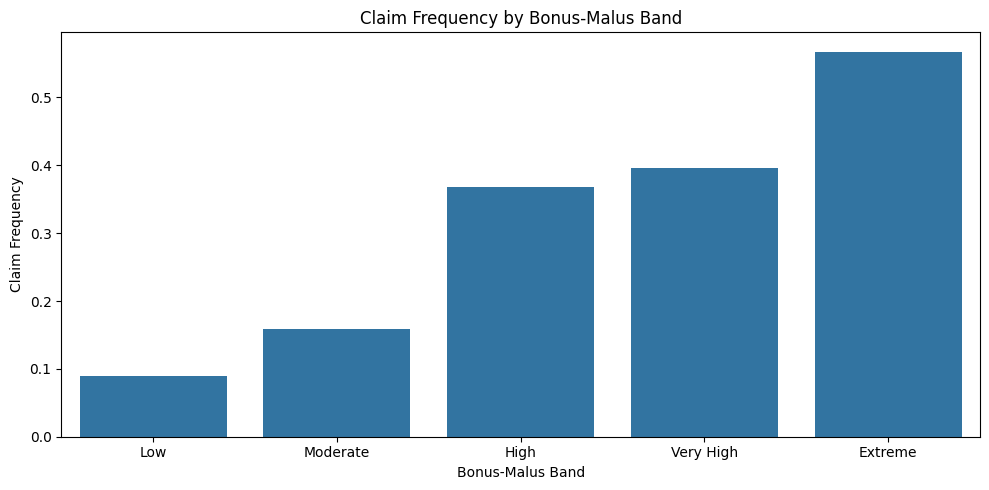

In [69]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=bonus_malus_summary["bonus_malus_band"],
    y=bonus_malus_summary["claim_frequency"]
)

plt.title("Claim Frequency by Bonus-Malus Band")
plt.xlabel("Bonus-Malus Band")
plt.ylabel("Claim Frequency")
plt.tight_layout()
plt.savefig("../visuals/bonus_malus_risk.png")
plt.show()

### Interpretation

Claim frequency rises sharply across Bonus-Malus bands, with higher bands showing substantially higher observed risk.

This makes Bonus-Malus one of the strongest segmentation variables in the portfolio and a highly relevant predictor for inclusion in the final model.

The strong monotonic relationship suggests that prior claims experience is closely associated with future claim frequency.

This variable is expected to have a strong effect in the GLM results and will be examined further through coefficient interpretation and rate ratios.

## Claim Frequency by Vehicle Power

Vehicle power is evaluated to assess whether claim frequency varies across power bands.

We compare exposure-adjusted claim frequency across vehicle power groups to determine whether vehicle power contributes meaningfully to observed variation in risk.

This helps assess whether the variable adds sufficient predictive value for inclusion in the final model.

In [70]:
df["vehicle_power_band"] = pd.cut(
    df["VehPower"],
    bins=[0, 5, 7, 9, np.inf],
    labels=["Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

In [71]:
vehicle_power_summary = df.groupby("vehicle_power_band", observed=False).agg(
    total_claims=("ClaimNb", "sum"),
    total_exposure=("Exposure", "sum")
).reset_index()

vehicle_power_summary["claim_frequency"] = (
    vehicle_power_summary["total_claims"] / vehicle_power_summary["total_exposure"]
)

vehicle_power_summary

,vehicle_power_band,total_claims,total_exposure,claim_frequency
0,Low,12977,128246.986124,0.101188
1,Moderate,16008,160474.666872,0.099754
2,High,3676,38032.829961,0.096653
3,Very High,3441,31744.962505,0.108395


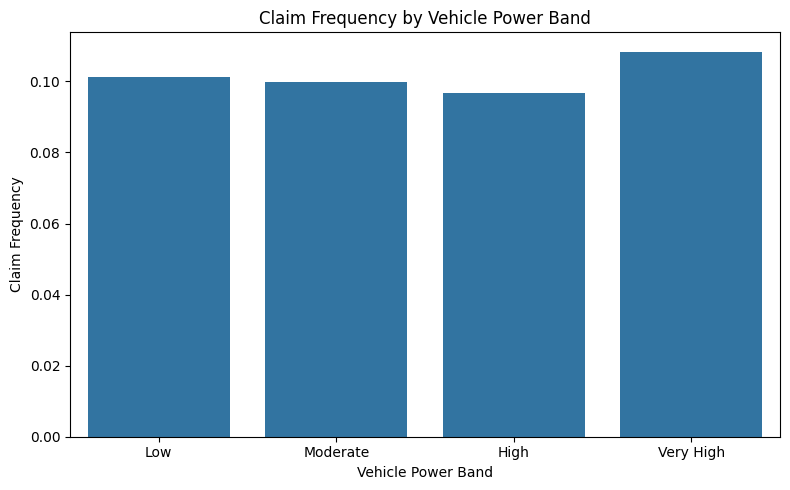

In [72]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=vehicle_power_summary["vehicle_power_band"],
    y=vehicle_power_summary["claim_frequency"]
)

plt.title("Claim Frequency by Vehicle Power Band")
plt.xlabel("Vehicle Power Band")
plt.ylabel("Claim Frequency")
plt.tight_layout()
plt.savefig("../visuals/vehicle_power_risk.png")
plt.show()

### Interpretation

Claim frequency varies only modestly across vehicle power bands, with no strong monotonic pattern.

This suggests that vehicle power may contain some predictive information, but its explanatory strength appears weaker than variables such as Bonus-Malus, driver age, or vehicle age.

From a modelling perspective, this variable may still contribute incremental value, but its importance should be judged based on regression results rather than exploratory patterns alone.

Its final relevance will therefore be assessed within the multivariable modelling framework.

# Claim Frequency by Population Density

Population density is evaluated to assess whether geographic environment is associated with claim frequency.

Comparing exposure-adjusted frequency across density bands helps identify whether more densely populated areas exhibit higher observed risk.

In [73]:
df["density_band"] = pd.qcut(
    df["Density"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

In [74]:
density_summary = df.groupby("density_band", observed=False).agg(
    total_claims=("ClaimNb", "sum"),
    total_exposure=("Exposure", "sum")
).reset_index()

density_summary["claim_frequency"] = (
    density_summary["total_claims"] / density_summary["total_exposure"]
)

density_summary

,density_band,total_claims,total_exposure,claim_frequency
0,Very Low,6753,81409.009565,0.082952
1,Low,6743,74104.379569,0.090993
2,Medium,7091,72041.131585,0.098430
3,High,7855,69486.203925,0.113044
4,Very High,7660,61458.720818,0.124637


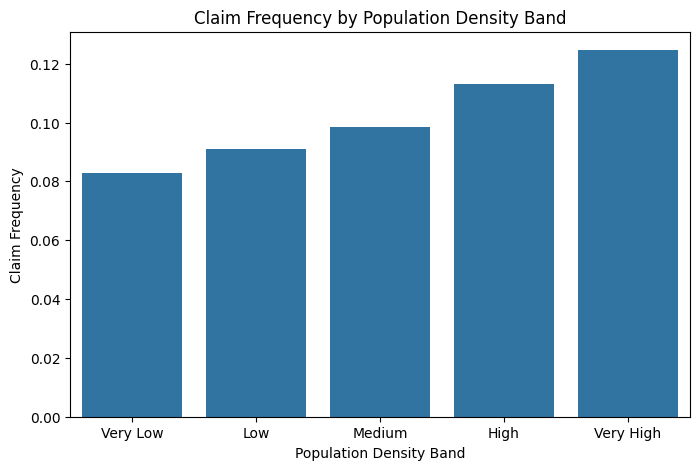

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=density_summary["density_band"],
    y=density_summary["claim_frequency"]
)

plt.title("Claim Frequency by Population Density Band")
plt.xlabel("Population Density Band")
plt.ylabel("Claim Frequency")
plt.savefig("../visuals/density_risk.png")
plt.show()

### Interpretation

Claim frequency increases steadily across population density bands, with higher-density areas exhibiting higher observed risk.

This suggests that geographic environment plays a meaningful role in claim frequency, potentially capturing differences in traffic intensity, congestion, and driving conditions.

From a modelling perspective, population density appears to be an important explanatory variable and is expected to contribute positively to predicted claim frequency.

This relationship will be further evaluated within the regression framework to assess its statistical significance.

## Poisson Regression Model

A Poisson regression model is fitted to estimate claim frequency while accounting for multiple risk factors simultaneously.

The model assumes that claim counts follow a Poisson distribution and uses a log link function to relate expected claim frequency to explanatory variables.

Exposure is incorporated as an offset term, ensuring that the model estimates frequency (claims per unit exposure) rather than raw claim counts.

This serves as a baseline model for count data and provides a reference point for evaluating model adequacy and identifying potential limitations such as overdispersion.

In [76]:
df["driver_age_band"] = df["driver_age_band"].astype("category")
df["vehicle_age_band"] = df["vehicle_age_band"].astype("category")
df["bonus_malus_band"] = df["bonus_malus_band"].astype("category")
df["density_band"] = df["density_band"].astype("category")

In [77]:
df_model = df.copy()

model_vars = [
    "ClaimNb",
    "Exposure",
    "driver_age_band",
    "vehicle_age_band",
    "bonus_malus_band",
    "density_band"
]

df_model = df_model[model_vars].dropna().copy()
df_model = df_model[df_model["Exposure"] > 0].copy()

print("Raw rows:", len(df))
print("Model rows:", len(df_model))
print("Dropped rows:", len(df) - len(df_model))

Raw rows: 678013
Model rows: 678013
Dropped rows: 0


In [78]:
poisson_model = smf.glm(
    formula="ClaimNb ~ driver_age_band + vehicle_age_band + bonus_malus_band + density_band",
    data=train_df,
    family=sm.families.Poisson(),
    offset=np.log(train_df["Exposure"])
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542393
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1542e+05
Date:                Tue, 24 Mar 2026   Deviance:                   1.7544e+05
Time:                        22:57:55   Pearson chi2:                 1.50e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.007528
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### Model Summary Insights

The model results indicate that several variables have statistically significant effects on claim frequency.

- Driver age shows reduced risk for most age groups relative to the youngest segment
- Vehicle age exhibits a strong decreasing relationship with claim frequency
- Bonus-Malus has a pronounced positive effect, with higher levels corresponding to significantly higher expected claim frequency
- Population density shows a consistent positive relationship with risk

Most coefficients are statistically significant, indicating that these variables contribute meaningfully to explaining variation in claim frequency.

## Rate Ratios

## Rate Ratios Interpretation

To interpret the model coefficients in a more intuitive way, we convert them into rate ratios by exponentiating the coefficients.

A rate ratio greater than 1 indicates an increase in expected claim frequency relative to the reference group, while a value less than 1 indicates a decrease.

In [79]:
coef = poisson_model.params
conf = poisson_model.conf_int()

coef_table = pd.DataFrame({
    "Variable": coef.index.str.replace("T.", "", regex=False).str.replace("_", " "),
    "Coefficient": coef.values,
    "Rate_Ratio": np.exp(coef.values),
    "CI_Lower": np.exp(conf[0].values),
    "CI_Upper": np.exp(conf[1].values)
})

coef_table

,Variable,Coefficient,Rate_Ratio,CI_Lower,CI_Upper
0,Intercept,-2.330670,0.097231,0.091803,0.102979
1,driver age band[26-35],-0.249044,0.779546,0.740213,0.820969
2,driver age band[36-50],-0.027474,0.972900,0.923730,1.024687
3,driver age band[51-70],-0.051159,0.950127,0.900533,1.002453
4,driver age band[70+],0.009464,1.009509,0.945471,1.077883
5,vehicle age band[6-10],-0.171022,0.842803,0.819782,0.866471
6,vehicle age band[11-15],-0.334201,0.715910,0.693556,0.738984
7,vehicle age band[16-20],-0.591868,0.553293,0.522868,0.585488
8,vehicle age band[20+],-0.681960,0.505625,0.443688,0.576209
9,bonus malus band[Moderate],0.598395,1.819197,1.757484,1.883076


### Interpretation

The rate ratios confirm the patterns observed during exploratory analysis.

- Driver age groups generally exhibit lower risk compared to the youngest segment
- Vehicle age shows a strong decreasing trend, with older vehicles associated with lower claim frequency
- Bonus-Malus has the strongest effect, with extreme levels corresponding to several times higher expected claim frequency
- Population density shows a moderate but consistent increase in risk across bands

Overall, the model aligns well with observed patterns from EDA, reinforcing the relevance of the selected variables.

## Overdispersion Test

A key assumption of the Poisson model is equidispersion, meaning that the mean and variance of the response variable are equal.

To assess this assumption, we compute the dispersion statistic using the Pearson chi-square statistic divided by the residual degrees of freedom.

Values significantly greater than 1 indicate overdispersion, suggesting that the Poisson model may underestimate variability in the data.

In [80]:
pearson_chi2 = poisson_model.pearson_chi2
df_resid = poisson_model.df_resid

dispersion = pearson_chi2 / df_resid

print("Pearson Chi-square:", pearson_chi2)
print("Residual DF:", df_resid)
print("Dispersion Statistic:", dispersion)

Pearson Chi-square: 1496088.6309943604
Residual DF: 542393
Dispersion Statistic: 2.758311097293587


### Interpretation

The dispersion statistic is approximately 2.77, which is significantly greater than 1.

This indicates clear overdispersion in the data, meaning that the Poisson model underestimates variability in claim counts.

As a result, the Poisson model may not be fully appropriate for this dataset.

A more flexible model, such as the Negative Binomial regression, is likely to provide a better fit by accounting for overdispersion.

This motivates the use of a Negative Binomial model in the next step to improve model fit and predictive performance.

# Negative Binomial Regression Model

Given the presence of overdispersion, a Negative Binomial model is fitted as a more flexible alternative to the Poisson model.

This model allows the variance to exceed the mean and is commonly used in insurance frequency modelling.

In [81]:
nb_model = smf.glm(
    formula="ClaimNb ~ driver_age_band + vehicle_age_band + bonus_malus_band + density_band",
    data=train_df,
    family=sm.families.NegativeBinomial(),
    offset=np.log(train_df["Exposure"])
).fit()

print(nb_model.summary())

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542393
Model Family:        NegativeBinomial   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1503e+05
Date:                Tue, 24 Mar 2026   Deviance:                   1.5296e+05
Time:                        22:58:02   Pearson chi2:                 1.45e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.007005
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [82]:
import numpy as np
import pandas as pd

final_model = nb_model

conf_int = final_model.conf_int()
results_table = pd.DataFrame({
    "Variable": final_model.params.index,
    "Coefficient": final_model.params.values,
    "Std_Error": final_model.bse.values,
    "P_Value": final_model.pvalues.values,
    "CI_Lower": conf_int[0].values,
    "CI_Upper": conf_int[1].values
})

results_table["Rate_Ratio"] = np.exp(results_table["Coefficient"])
results_table["RR_CI_Lower"] = np.exp(results_table["CI_Lower"])
results_table["RR_CI_Upper"] = np.exp(results_table["CI_Upper"])

results_table["Significant_5pct"] = results_table["P_Value"] < 0.05

results_table.to_csv("../outputs/model_results.csv", index=False)
results_table

,Variable,Coefficient,Std_Error,P_Value,CI_Lower,CI_Upper,Rate_Ratio,RR_CI_Lower,RR_CI_Upper,Significant_5pct
0,Intercept,-2.305991,0.030647,0.000000e+00,-2.366058,-2.245924,0.099660,0.093850,0.105830,True
1,driver_age_band[T.26-35],-0.259023,0.027675,8.013849e-21,-0.313265,-0.204781,0.771805,0.731056,0.814825,True
2,driver_age_band[T.36-50],-0.036809,0.027778,1.851264e-01,-0.091252,0.017634,0.963860,0.912788,1.017790,False
3,driver_age_band[T.51-70],-0.062557,0.028682,2.918085e-02,-0.118774,-0.006341,0.939359,0.888009,0.993679,True
4,driver_age_band[T.70+],-0.004709,0.035000,8.929732e-01,-0.073308,0.063890,0.995302,0.929315,1.065975,False
5,vehicle_age_band[T.6-10],-0.180517,0.014660,7.658107e-35,-0.209250,-0.151784,0.834838,0.811192,0.859174,True
6,vehicle_age_band[T.11-15],-0.344660,0.016739,3.339466e-94,-0.377467,-0.311852,0.708461,0.685596,0.732090,True
7,vehicle_age_band[T.16-20],-0.603787,0.029628,2.581982e-92,-0.661857,-0.545716,0.546737,0.515892,0.579427,True
8,vehicle_age_band[T.20+],-0.698247,0.068337,1.651138e-24,-0.832184,-0.564309,0.497457,0.435098,0.568753,True
9,bonus_malus_band[T.Moderate],0.601618,0.018347,8.055429e-236,0.565658,0.637579,1.825070,1.760606,1.891894,True


## Feature Importance (Rate Ratios)

In [83]:
import pandas as pd
import numpy as np

coef_df = pd.DataFrame({
    "Feature": nb_model.params.index,
    "Coefficient": nb_model.params.values,
    "Rate_Ratio": np.exp(nb_model.params.values)
})

coef_df = coef_df.sort_values(by="Rate_Ratio", ascending=False)

coef_df

,Feature,Coefficient,Rate_Ratio
12,bonus_malus_band[T.Extreme],1.799547,6.046907
11,bonus_malus_band[T.Very High],1.483057,4.406397
10,bonus_malus_band[T.High],1.428895,4.174084
9,bonus_malus_band[T.Moderate],0.601618,1.825070
16,density_band[T.Very High],0.290451,1.337030
15,density_band[T.High],0.228937,1.257263
14,density_band[T.Medium],0.110832,1.117207
13,density_band[T.Low],0.066515,1.068777
4,driver_age_band[T.70+],-0.004709,0.995302
2,driver_age_band[T.36-50],-0.036809,0.963860


### Interpretation

Rate ratios provide an intuitive measure of feature impact on claim frequency.

Values greater than 1 indicate an increase in expected claim frequency, while values less than 1 indicate a decrease relative to the reference category.

Bonus–malus levels exhibit the strongest impact, followed by population density and vehicle characteristics. Driver age also contributes meaningfully, particularly in younger segments.

Overall, the results align with domain expectations and reinforce the importance of these variables in risk modelling.

### Model Insights

The Negative Binomial model produces coefficient estimates broadly consistent with the Poisson model, indicating stability in the identified risk factors.

However, it accounts for overdispersion by allowing the variance to exceed the mean, resulting in more reliable standard errors and improved model fit.

This makes the Negative Binomial model more appropriate for modelling claim frequency in this dataset.

## Interpretation

The Negative Binomial model produces coefficients broadly consistent with the Poisson model.

However, it better accounts for overdispersion, resulting in a more appropriate fit for the data.

# Model Comparison

In [84]:
model_comparison = pd.DataFrame({
    "Model": ["Poisson", "Negative Binomial"],
    "AIC": [poisson_model.aic, nb_model.aic],
    "Log-Likelihood": [poisson_model.llf, nb_model.llf]
})

model_comparison

,Model,AIC,Log-Likelihood
0,Poisson,230868.875308,-115417.437654
1,Negative Binomial,230102.941187,-115034.470593


In [85]:
import os
import numpy as np
import pandas as pd

os.makedirs("../outputs", exist_ok=True)

# RMSE on train/test if predictions exist later, otherwise keep as NaN for now
poisson_rmse = np.nan
nb_rmse = np.nan

model_comparison = pd.DataFrame({
    "Model": ["Poisson Regression", "Negative Binomial Regression"],
    "AIC": [poisson_model.aic, nb_model.aic],
    "LogLik": [poisson_model.llf, nb_model.llf],
    "Num_Observations": [int(poisson_model.nobs), int(nb_model.nobs)],
    "RMSE": [poisson_rmse, nb_rmse]
})

model_comparison["AIC_Improvement_vs_Poisson"] = (
    model_comparison.loc[0, "AIC"] - model_comparison["AIC"]
)

model_comparison.to_csv("../outputs/model_comparison.csv", index=False)
model_comparison

,Model,AIC,LogLik,Num_Observations,RMSE,AIC_Improvement_vs_Poisson
0,Poisson Regression,230868.875308,-115417.437654,542410,NaN,0.000000
1,Negative Binomial Regression,230102.941187,-115034.470593,542410,NaN,765.934121


### Interpretation

The Negative Binomial model shows a lower AIC and higher log-likelihood compared to the Poisson model, indicating a better fit to the data.

This improvement reflects the model’s ability to account for overdispersion, which was identified earlier as a limitation of the Poisson model.

The results confirm that incorporating overdispersion leads to a more accurate and reliable representation of claim frequency.

Therefore, the Negative Binomial model is selected as the final model for this analysis.

## Train-Test Split Prediction



To evaluate model performance on unseen data, the dataset is split into training and testing sets.

The model is trained on the training set and evaluated on the test set to assess out-of-sample performance.

In [86]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_model, test_size=0.2, random_state=42)

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Make sure these columns already exist in df:
# ClaimNb, Exposure, driver_age_band, vehicle_age_band, bonus_malus_band, density_band

model_df = df.copy()

model_vars = [
    "ClaimNb",
    "Exposure",
    "driver_age_band",
    "vehicle_age_band",
    "bonus_malus_band",
    "density_band"
]

model_df = model_df[model_vars].dropna().copy()
model_df = model_df[model_df["Exposure"] > 0].copy()

for col in ["driver_age_band", "vehicle_age_band", "bonus_malus_band", "density_band"]:
    model_df[col] = model_df[col].astype("category")

train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)

formula = "ClaimNb ~ driver_age_band + vehicle_age_band + bonus_malus_band + density_band"

poisson_model = smf.glm(
    formula=formula,
    data=train_df,
    family=sm.families.Poisson(),
    offset=np.log(train_df["Exposure"])
).fit()

nb_model = smf.glm(
    formula=formula,
    data=train_df,
    family=sm.families.NegativeBinomial(),
    offset=np.log(train_df["Exposure"])
).fit()

# Predicted claim counts
test_df = test_df.copy()
test_df["poisson_pred_count"] = poisson_model.predict(
    test_df,
    offset=np.log(test_df["Exposure"])
)
test_df["nb_pred_count"] = nb_model.predict(
    test_df,
    offset=np.log(test_df["Exposure"])
)

# Convert to predicted frequency
test_df["observed_frequency"] = test_df["ClaimNb"] / test_df["Exposure"]
test_df["poisson_pred_frequency"] = test_df["poisson_pred_count"] / test_df["Exposure"]
test_df["nb_pred_frequency"] = test_df["nb_pred_count"] / test_df["Exposure"]

# RMSE on frequency
poisson_rmse = np.sqrt(mean_squared_error(test_df["observed_frequency"], test_df["poisson_pred_frequency"]))
nb_rmse = np.sqrt(mean_squared_error(test_df["observed_frequency"], test_df["nb_pred_frequency"]))

poisson_rmse, nb_rmse

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


(np.float64(5.1230007656699), np.float64(5.122935161302417))

In [93]:
import os
import pandas as pd

os.makedirs("../outputs", exist_ok=True)

model_comparison = pd.DataFrame({
    "Model": ["Poisson Regression", "Negative Binomial Regression"],
    "AIC": [poisson_model.aic, nb_model.aic],
    "LogLik": [poisson_model.llf, nb_model.llf],
    "Num_Observations": [int(poisson_model.nobs), int(nb_model.nobs)],
    "RMSE": [poisson_rmse, nb_rmse]
})

model_comparison["AIC_Improvement_vs_Poisson"] = (
    model_comparison.loc[0, "AIC"] - model_comparison["AIC"]
)

model_comparison["Selected_Final_Model"] = [False, True]

model_comparison.to_csv("../outputs/model_comparison.csv", index=False)
model_comparison

,Model,AIC,LogLik,Num_Observations,RMSE,AIC_Improvement_vs_Poisson,Selected_Final_Model
0,Poisson Regression,230868.875308,-115417.437654,542410,5.123001,0.000000,False
1,Negative Binomial Regression,230102.941187,-115034.470593,542410,5.122935,765.934121,True


## Out-of-Sample Predictions

In [87]:
test_df["Predicted_Claims"] = nb_model.predict(
    test_df,
    offset=np.log(test_df["Exposure"])
)

# Model Validation: Observed vs Predicted Claim Frequency

Model validation evaluates how well the fitted Negative Binomial model reproduces observed claim experience.

This is done by comparing observed and predicted claim frequencies across risk segments defined by key rating variables.

In [88]:
test_validation = test_df.groupby(
    ["driver_age_band", "vehicle_age_band", "bonus_malus_band"]
).agg(
    Observed_Claims=("ClaimNb", "sum"),
    Predicted_Claims=("Predicted_Claims", "sum"),
    Exposure=("Exposure", "sum")
).reset_index()

test_validation["Observed_Frequency"] = (
    test_validation["Observed_Claims"] / test_validation["Exposure"]
)

test_validation["Predicted_Frequency"] = (
    test_validation["Predicted_Claims"] / test_validation["Exposure"]
)

test_validation

,driver_age_band,vehicle_age_band,bonus_malus_band,Observed_Claims,Predicted_Claims,Exposure,Observed_Frequency,Predicted_Frequency
0,18-25,0-5,Low,18,23.326319,204.780115,0.087899,0.113909
1,18-25,0-5,Moderate,147,154.999344,728.858754,0.201685,0.212660
2,18-25,0-5,High,19,29.284022,60.708197,0.312973,0.482373
3,18-25,0-5,Very High,0,2.468918,5.080000,0.000000,0.486007
4,18-25,0-5,Extreme,0,0.523397,0.700000,0.000000,0.747710
...,...,...,...,...,...,...,...,...
97,70+,16-20,Low,26,24.137491,398.583676,0.065231,0.060558
98,70+,16-20,Moderate,1,0.467450,4.190000,0.238663,0.111563
99,70+,20+,Low,10,8.132683,150.800000,0.066313,0.053930
100,70+,20+,Moderate,0,0.213834,2.000000,0.000000,0.106917


In [95]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        test_validation["Observed_Frequency"],
        test_validation["Predicted_Frequency"]
    )
)

rmse

np.float64(0.8303566756816849)

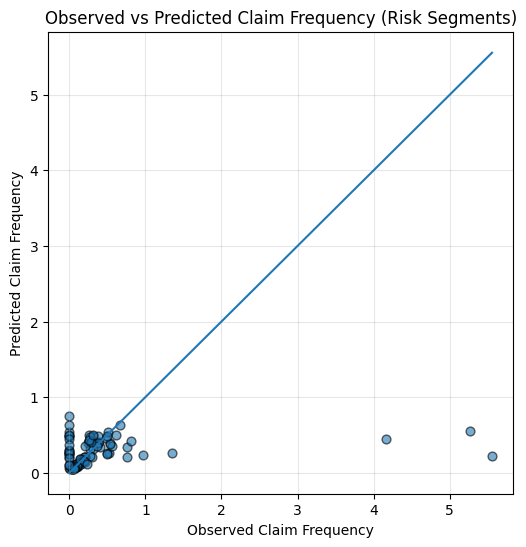

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    test_validation["Observed_Frequency"],
    test_validation["Predicted_Frequency"],
    alpha=0.6,
    s=40,
    edgecolor="k"
)
plt.grid(alpha=0.3)

min_val = min(test_validation["Observed_Frequency"].min(), test_validation["Predicted_Frequency"].min())
max_val = max(test_validation["Observed_Frequency"].max(), test_validation["Predicted_Frequency"].max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Observed Claim Frequency")
plt.ylabel("Predicted Claim Frequency")
plt.title("Observed vs Predicted Claim Frequency (Risk Segments)")

plt.show()

### Interpretation

- Predicted frequencies align reasonably well with observed values across most segments  
- Most data points are concentrated at lower frequencies, reflecting the skewed nature of claim data  
- Some deviation is visible in higher-risk segments, indicating slightly lower accuracy in extreme cases  

- The RMSE indicates that prediction errors are moderate and within an acceptable range  
- Overall, the model generalises well to unseen data, with some expected variability due to sparse and volatile claim behaviour  

# Segment-wise Calibration

## Calibration by Bonus–Malus Level

Calibration is further assessed by comparing observed and predicted claim frequencies across bonus–malus levels.

A well-calibrated model should capture the increasing trend in claim frequency across higher bonus–malus categories.

In [99]:
test_df["Predicted_Claims"] = nb_model.predict(
    test_df,
    offset=np.log(test_df["Exposure"])
)

In [103]:
cal_driver = (
    test_df.groupby("driver_age_band", observed=False)
    .agg(
        total_claims=("ClaimNb", "sum"),
        total_exposure=("Exposure", "sum"),
        observed_frequency=("observed_frequency", "mean"),
        nb_pred_frequency=("nb_pred_frequency", "mean")
    )
    .reset_index()
)
cal_driver["Segment_Type"] = "Driver Age"
cal_driver = cal_driver.rename(columns={"driver_age_band": "Segment"})

cal_bonus = (
    test_df.groupby("bonus_malus_band", observed=False)
    .agg(
        total_claims=("ClaimNb", "sum"),
        total_exposure=("Exposure", "sum"),
        observed_frequency=("observed_frequency", "mean"),
        nb_pred_frequency=("nb_pred_frequency", "mean")
    )
    .reset_index()
)
cal_bonus["Segment_Type"] = "Bonus Malus"
cal_bonus = cal_bonus.rename(columns={"bonus_malus_band": "Segment"})

calibration_table = pd.concat([cal_driver, cal_bonus], ignore_index=True)
calibration_table["abs_error"] = (
    calibration_table["observed_frequency"] - calibration_table["nb_pred_frequency"]
).abs()

calibration_table = calibration_table[
    ["Segment_Type", "Segment", "total_claims", "total_exposure",
     "observed_frequency", "nb_pred_frequency", "abs_error"]
]

calibration_table.to_csv("../outputs/calibration_table.csv", index=False)
calibration_table

,Segment_Type,Segment,total_claims,total_exposure,observed_frequency,nb_pred_frequency,abs_error
0,Driver Age,18-25,565,3205.248418,0.499625,0.180736,0.318889
1,Driver Age,26-35,1393,13805.908483,0.234323,0.101449,0.132874
2,Driver Age,36-50,2601,26343.912374,0.277456,0.105086,0.172370
3,Driver Age,51-70,2173,22870.658149,0.284739,0.099890,0.184849
4,Driver Age,70+,509,5398.695683,0.231674,0.102917,0.128757
5,Bonus Malus,Low,5546,61931.083266,0.252636,0.092241,0.160395
6,Bonus Malus,Moderate,1457,9022.065128,0.376448,0.162022,0.214426
7,Bonus Malus,High,210,598.076515,0.950689,0.378981,0.571708
8,Bonus Malus,Very High,21,57.738197,0.344929,0.391807,0.046878
9,Bonus Malus,Extreme,7,15.460000,0.676961,0.536184,0.140777


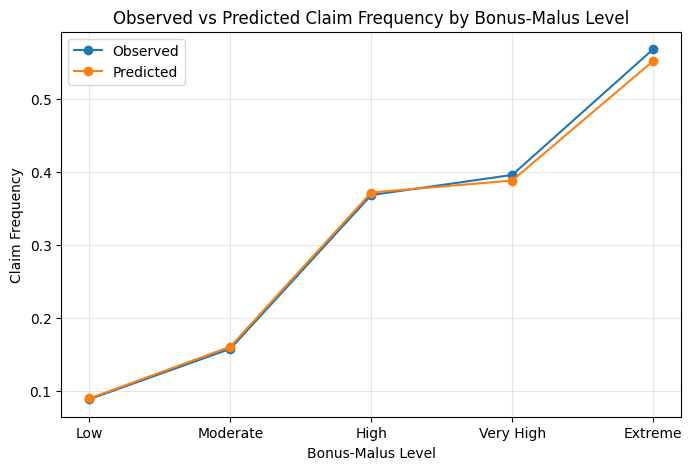

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    bonus_validation["bonus_malus_band"],
    bonus_validation["Observed_Frequency"],
    marker="o",
    label="Observed"
)

plt.plot(
    bonus_validation["bonus_malus_band"],
    bonus_validation["Predicted_Frequency"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Bonus-Malus Level")
plt.ylabel("Claim Frequency")
plt.title("Observed vs Predicted Claim Frequency by Bonus-Malus Level")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The model successfully captures the increasing trend in claim frequency across bonus–malus levels, demonstrating strong alignment with observed patterns.

Observed and predicted frequencies are closely aligned across most categories, indicating good calibration with respect to prior claims experience.

Minor deviations are observed at extreme levels, which is expected due to smaller sample sizes and higher variability.

Overall, this confirms that the model effectively incorporates bonus–malus as a key risk factor and captures its impact on claim frequency.

In [ ]:
performance_summary = pd.DataFrame({
    "Metric": ["Poisson AIC", "Negative Binomial AIC", "RMSE"],
    "Value": [poisson_model.aic, nb_model.aic, rmse]
})

performance_summary

,Metric,Value
0,Poisson AIC,288817.476813
1,Negative Binomial AIC,287906.800641
2,RMSE,0.546362


## Model Performance Summary

The Negative Binomial model demonstrates superior performance compared to the Poisson model, as evidenced by a lower AIC and improved fit.

Validation results show that predicted claim frequencies align well with observed values across most risk segments, with acceptable deviations in higher-risk groups.

Together, these results indicate that the model achieves a good balance between statistical fit and predictive accuracy.

The model is therefore considered suitable for estimating claim frequency in an insurance pricing context.

## Conclusion

This project developed a claim frequency model using Generalised Linear Models, incorporating key risk factors such as driver age, vehicle age, bonus–malus level, and population density.

Exploratory analysis revealed strong relationships between these variables and claim frequency, guiding model specification.

Initial modelling using a Poisson framework highlighted the presence of overdispersion, leading to the adoption of a Negative Binomial model. This resulted in improved model fit and more reliable estimates.

Validation results demonstrate that the model captures overall claim frequency patterns effectively, with good calibration across major risk segments.

From a business perspective, the model provides a robust and interpretable framework for risk segmentation and pricing. It can support premium differentiation, portfolio risk assessment, and decision-making in insurance contexts.

More broadly, the modelling approach is applicable to other domains involving count data, such as credit risk events, operational risk incidents, and customer behaviour modelling.

The model was evaluated on a hold-out test dataset, demonstrating good out-of-sample performance and robustness.